In [1]:
import numpy as np
import os
import matplotlib.pyplot as plt
import xarray as xr
import rioxarray as riox
import seaborn as sns
import geopandas as gpd

#### Input/Ouput paths

In [63]:
from rasterio.plot import show
from matplotlib.patches import Patch
import matplotlib.transforms as mtransforms
from matplotlib.patches import FancyBboxPatch
import matplotlib.animation as animation

In [64]:
yr = str(2021)

inPATH_ndvi = f'/90daydata/cper_neon_aop/hls_nrt/cper/hls_ndvi/cper_hls_ndvi_{yr}.nc'
ds_ndvi = riox.open_rasterio(inPATH_ndvi, masked=True)

inPATH_bm = f'/90daydata/cper_neon_aop/hls_nrt/cper/hls_biomass/cper_hls_bm_{yr}.nc'
ds_bm = riox.open_rasterio(inPATH_bm, masked=True)

inPATH_shp = '../../data/ground/boundaries/cper_pastures_2022_w_exclosures_spk.shp'
gdf_pasts = gpd.read_file(inPATH_shp)
gdf_pasts = gdf_pasts.to_crs(crs=ds_bm.rio.crs.to_epsg())

In [65]:
ds_bm = ds_bm.rename({'time': 'date'})

In [66]:
dates = [x for x in ds_bm.date]

In [67]:
#gdf_pasts

### Create and save single year gif with timeseries line plot for custom area

In [68]:
from shapely.geometry import Polygon
import matplotlib.dates as mdates
import pandas as pd
import geopandas as gpd
from rasterio.plot import show

In [86]:
# manually create the two AOI's (used the approx bounds of two of the tower sites GPS coords)
#aoi1 = gpd.GeoSeries(Polygon(((662905.13, 3756330.15),
#                              (662903.43, 3756409.31),
#                              (663003.76, 3756411.85),
#                              (663005.45, 3756331.84))))
#aoi2 = gpd.GeoSeries(Polygon(((663921.09, 3755925.03),
#                              (663919.82, 3756005.46),
#                              (664021.41, 3756007.58),
#                              (664020.57, 3755926.30))))

aoi1 = gdf_pasts[gdf_pasts['Past_Name_'] == '31E'].geometry
aoi2 = gdf_pasts[gdf_pasts['Past_Name_'] == '15E'].geometry

In [87]:
# create empty time series for AOI 1 equal to the length of the dates vector
ts_bm1 = np.array(np.repeat(np.nan, len(dates)))
# fill the first value of the time series with the mean from the AOI on the first date
ts_bm1[0] = ds_bm.sel(date=dates[0], 
                      x=slice(aoi1.total_bounds[0], aoi1.total_bounds[2]),
                      y=slice(aoi1.total_bounds[3], aoi1.total_bounds[1])).mean().data
# create a full time series values with all the dates
ts_bm1_all = ds_bm.sel(date=slice(dates[0], dates[-1]),
                       x=slice(aoi1.total_bounds[0], aoi1.total_bounds[2]),
                       y=slice(aoi1.total_bounds[3], aoi1.total_bounds[1])).mean(dim=['y', 'x']).data

In [88]:
# create empty time series for AOI 1 equal to the length of the dates vector
ts_bm2 = np.array(np.repeat(np.nan, len(dates)))
# fill the first value of the time series with the mean from the AOI on the first date
ts_bm2[0] = ds_bm.sel(date=dates[0], 
                      x=slice(aoi2.total_bounds[0], aoi2.total_bounds[2]),
                      y=slice(aoi2.total_bounds[3], aoi2.total_bounds[1])).mean().data
# create a full time series values with all the dates
ts_bm2_all = ds_bm.sel(date=slice(dates[0], dates[-1]),
                       x=slice(aoi2.total_bounds[0], aoi2.total_bounds[2]),
                       y=slice(aoi2.total_bounds[3], aoi2.total_bounds[1])).mean(dim=['y', 'x']).data

In [89]:
# month-only formatter for x-axis on time series plot
myFmt = mdates.DateFormatter('%b')

In [90]:
# get the date values for the time series plot
ts_dates = np.array([pd.to_datetime(x.values.item().isoformat()).to_pydatetime() for x in dates])

In [91]:
# set duration of the gif
duration_secs = 12
# set the number of xarray pixels per inch of figure
#pixpi_out=20
pixpi_out = 25

In [92]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

# --- Style ---
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': 'Arial',
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.linewidth': 0.8,
    'axes.grid': True,
    'grid.color': '#e0e0e0',
    'grid.linewidth': 0.6,
    'grid.linestyle': '--',
    'xtick.direction': 'out',
    'ytick.direction': 'out',
    'xtick.major.size': 4,
    'ytick.major.size': 4,
    'lines.linewidth': 2,
    'legend.frameon': False,
    'figure.dpi': 150,
})


/local/scratch/sean.kearney/19617510/ipykernel_1642955/3016333131.py:48: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  cb = fig.colorbar(im_for_legend, cax=cax, orientation='horizontal',


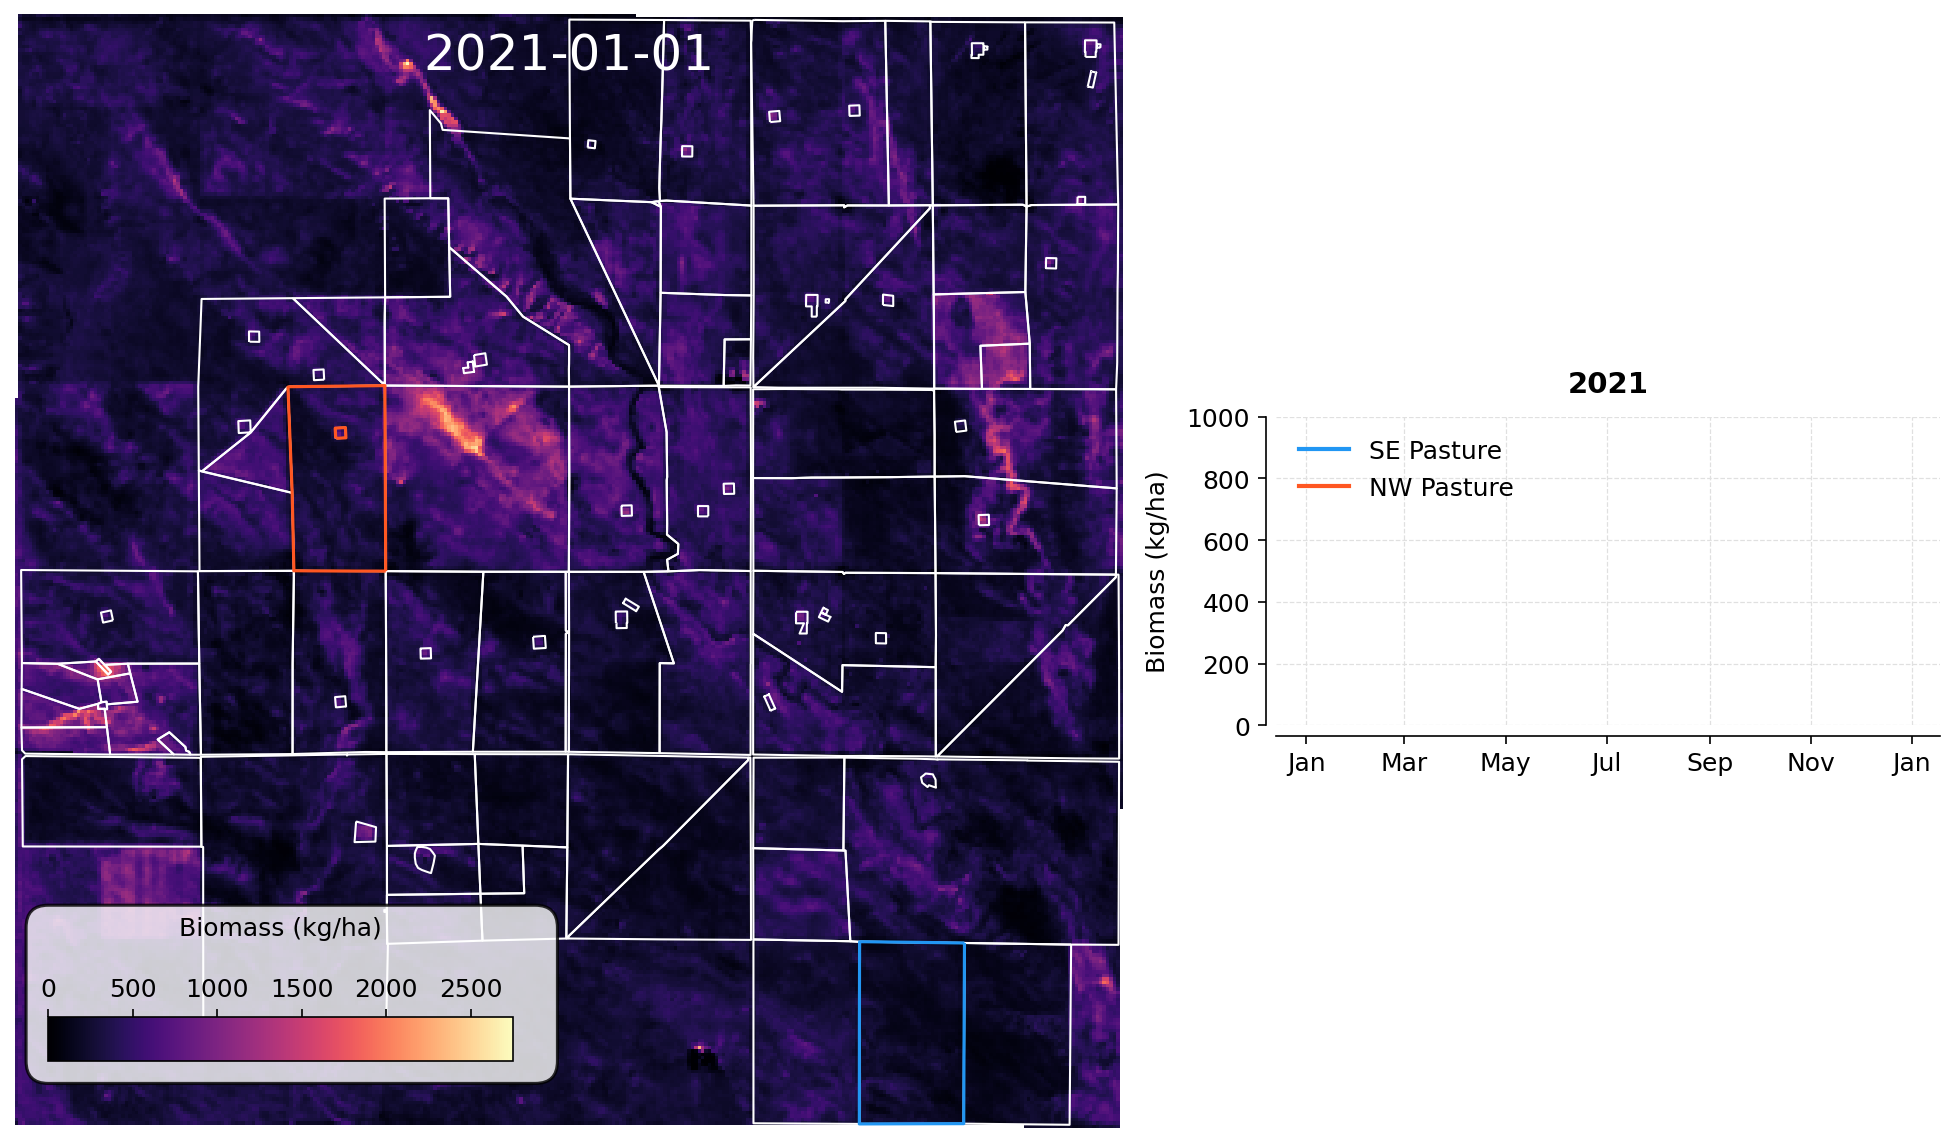

In [95]:
# create figure and axis with automatic size based on pixels/inch set above, adjusting for additional subplot
fig = plt.figure(figsize=(len(ds_bm.x)/pixpi_out, (len(ds_bm.y)/pixpi_out)*0.6), layout='constrained')
# create the gridspec for multiple rows/columns to be able to center subplot
gs = fig.add_gridspec(3, 3, width_ratios=[1.0, 0.01, 0.6])

# create the map axis spanning all rows of gridspec
ax1 = fig.add_subplot(gs[:, 0])
# center the map PROBABLY NOT NEEDED
ax1.set_anchor('C')
# turn off the axis ticks/labels on the map
ax1.axis('off')
# create the map
im = show(ds_bm.sel(date=dates[0]).data, vmin=0, vmax=2750, animated=True,
              transform=ds_bm.rio.transform(), ax=ax1, cmap='magma')
# get the image from the map
im_for_legend = im.get_images()[0]
# plot the ranch boundary
#gdf_aoi.boundary.plot(ax=ax1, edgecolor='white', linewidth=0.5)
#gdf_pasts[gdf_pasts['Treatment'] == 'AD'].plot(ax=ax, edgecolor='red', facecolor="none", linewidth=1.25)
#gdf_pasts[gdf_pasts['Treatment'] == 'PR'].plot(ax=ax, edgecolor='cyan', facecolor="none", linewidth=1.25)
gdf_pasts.plot(ax=ax1, edgecolor='white', facecolor="none", linewidth=1.0)
# plot the two AOI's defined above
aoi1.boundary.plot(ax=ax1, edgecolor='#2196F3', linewidth=1.5)
aoi2.boundary.plot(ax=ax1, edgecolor='#FF5722', linewidth=1.5)
# add the text annotation for the date
date_text = ax1.text(0.5, 0.95, 
                    dates[0].dt.floor('D').dt.strftime("%Y-%m-%d").values,
                    c='white', size=24, horizontalalignment='center', fontweight=500,
                    transform=ax1.transAxes, animated=True)

# legend stuff for map
# Add a box in axes coordinates (0–1 range)
box = FancyBboxPatch(
    (0.03, 0.06),          # (x, y) bottom-left corner in axes coords
    0.44, 0.12,            # width, height
    boxstyle="round,pad=0.02",
    transform=ax1.transAxes,  # use axes coordinates
    facecolor='white',
    edgecolor='black',
    linewidth=1.5,
    alpha=0.8,
    zorder=5               # draw on top of the image
)
ax1.add_patch(box)
# create a colorbar for the map
cax = ax1.inset_axes([0.03, 0.06, 0.42, 0.04])
cax.patch.set(facecolor='white', alpha=0.7)
cb = fig.colorbar(im_for_legend, cax=cax, orientation='horizontal', 
                  label='Biomass (kg/ha)',
                 )

# flip the axis ticks and label of the colorbar to be on top
cb.ax.xaxis.set_ticks_position("top")
cb.ax.xaxis.set_label_position("top")
cb.ax.tick_params(labelsize=12)       # tick labels
cb.set_label('Biomass (kg/ha)', size=12)  # colorbar label
cb.ax.xaxis.labelpad = 20  # increase to add more space

# create the subplot axis for the timeseries in the okddle row of the third column
ax2 = fig.add_subplot(gs[1, 2])
# anchor to center PROBABLY NOT NEEDED
ax2.set_anchor('C')
# create invisible plot with all dates and data for aoi1 to get the axis liokts right
ax2.plot(ts_dates, ts_bm1_all, linewidth=0)
# manually set the liokt for the y axis
ax2.set_ylim((0, 1000))

#ts1 = ax2.plot(ts_dates, ts_bm1_all, color='#2196F3', label='Heavy')
#ts2 = ax2.plot(ts_dates, ts_bm2_all, color='#FF5722', label='Light')
ts1 = ax2.plot(ts_dates, ts_bm1, color='#2196F3', label='SE Pasture')
ts2 = ax2.plot(ts_dates, ts_bm2, color='#FF5722', label='NW Pasture')
ax2.set_xlabel('', labelpad=8)
ax2.set_ylabel('Biomass (kg/ha)', labelpad=8, fontsize=12)
ax2.set_title(str(yr), fontsize=14, fontweight='bold', pad=12)
ax2.legend(loc='upper left', fontsize=12)
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b'))  # 'Jan 2024'
# Offset the axes slightly for a cleaner look
ax2.spines['left'].set_position(('outward', 5))
ax2.spines['bottom'].set_position(('outward', 5))
ax2.tick_params(axis='both', labelsize=12)
#fig.tight_layout()

In [ ]:
def animate_xr_ts_aoi(frame):
    im.images[0].set_data(ds_bm.sel(date=dates[frame]).data)
    date_text.set_text(dates[frame].dt.floor('D').dt.strftime("%Y-%m-%d").values)
    ts1[0].set_ydata(np.concatenate((ts_bm1_all[:frame], ts_bm1[frame:])))
    ts2[0].set_ydata(np.concatenate((ts_bm2_all[:frame], ts_bm2[frame:])))
    return (im, date_text, ts1, ts2)

ani = animation.FuncAnimation(fig, animate_xr_ts_aoi, interval=200,
                              frames=len(dates), repeat=False, repeat_delay=1000)

writer = animation.PillowWriter(fps=len(dates)//duration_secs)
ani.save(os.path.join('cper_anims', 'cper_anim_bm_se_vs_nw_' + str(yr) + '.gif'), 
         dpi=150,
         writer=writer,
         savefig_kwargs={'transparent': True, 'pad_inches': 0},
         progress_callback=lambda i, n: print(f'Saving frame {i+1} of {n}', end='\r'))

Saving frame 6 of 365

In [145]:
yr = str(2021)

inPATH_ndvi = f'/90daydata/cper_neon_aop/hls_nrt/cper/hls_ndvi/cper_hls_ndvi_{yr}.nc'
ds_ndvi = riox.open_rasterio(inPATH_ndvi, masked=True)

inPATH_bm = f'/90daydata/cper_neon_aop/hls_nrt/cper/hls_biomass/cper_hls_bm_{yr}.nc'
ds_bm = riox.open_rasterio(inPATH_bm, masked=True)

inPATH_shp = '../../data/ground/boundaries/cper_pastures_2022_w_exclosures_spk.shp'
gdf_pasts = gpd.read_file(inPATH_shp)
gdf_pasts = gdf_pasts.to_crs(crs=ds_bm.rio.crs.to_epsg())

In [146]:
ds_bm = ds_bm.rename({'time': 'date'})

In [147]:
dates = [x for x in ds_bm.date]

In [153]:
aoi1 = gdf_pasts[gdf_pasts['CARM_Name'] == '31E'].geometry
# create a full time series values with all the dates
ts_bm1_all = ds_bm.sel(date=slice(dates[0], dates[-1]),
                       x=slice(aoi1.total_bounds[0], aoi1.total_bounds[2]),
                       y=slice(aoi1.total_bounds[3], aoi1.total_bounds[1])).mean(dim=['y', 'x']).data

In [155]:
aoi2 = gdf_pasts[gdf_pasts['CARM_Name'] == '15E'].geometry
# create a full time series values with all the dates
ts_bm2_all = ds_bm.sel(date=slice(dates[0], dates[-1]),
                       x=slice(aoi2.total_bounds[0], aoi2.total_bounds[2]),
                       y=slice(aoi2.total_bounds[3], aoi2.total_bounds[1])).mean(dim=['y', 'x']).data

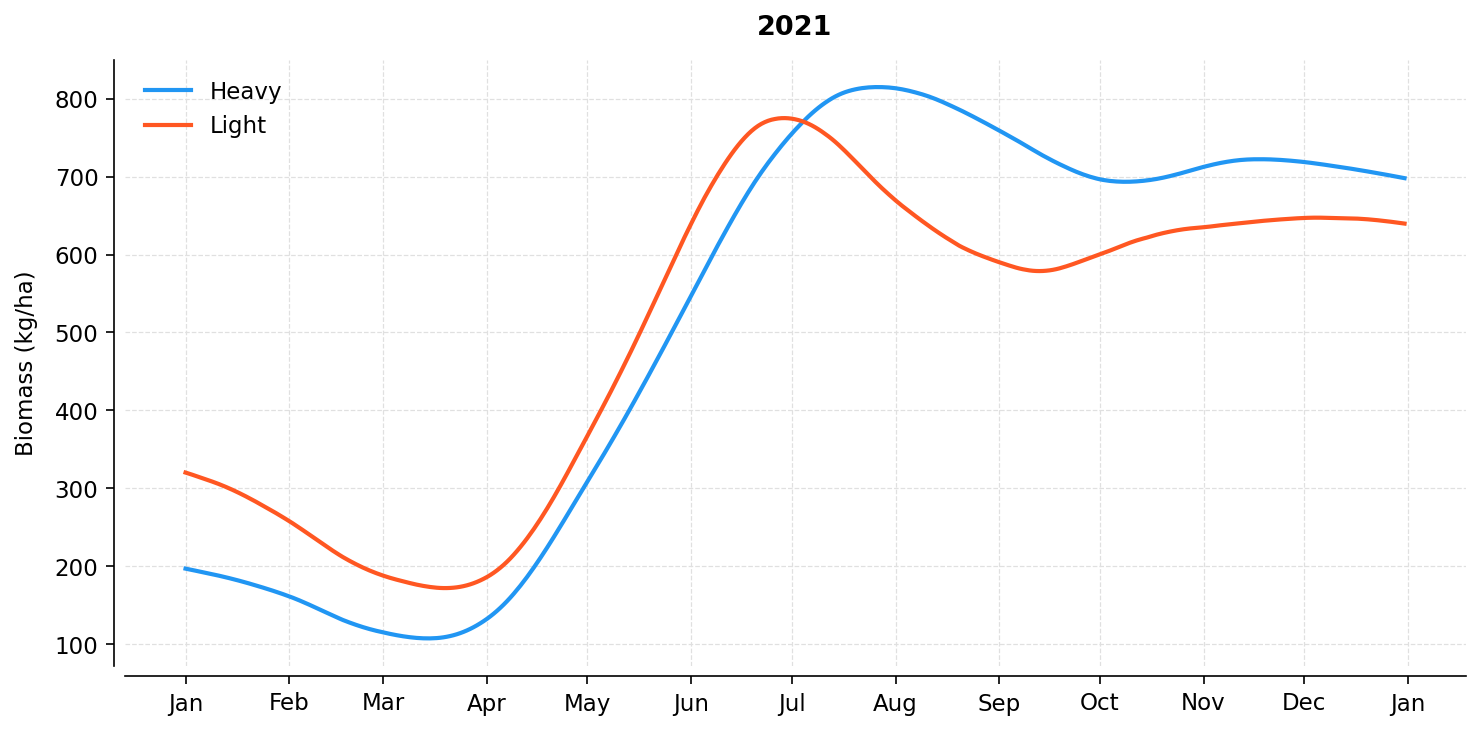

In [157]:
fig, ax = plt.subplots(figsize=(10, 5))
ts1 = ax.plot(ts_dates, ts_bm1_all, color='#2196F3', label='Heavy')
ts2 = ax.plot(ts_dates, ts_bm2_all, color='#FF5722', label='Light')
ax.set_xlabel('', labelpad=8)
ax.set_ylabel('Biomass (kg/ha)', labelpad=8)
ax.set_title(str(yr), fontsize=13, fontweight='bold', pad=12)
ax.legend(loc='upper left')

ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))  # 'Jan 2024'

# Offset the axes slightly for a cleaner look
ax.spines['left'].set_position(('outward', 5))
ax.spines['bottom'].set_position(('outward', 5))

fig.tight_layout()

In [14]:
# set duration of the gif
duration_secs = 12
# set the number of xarray pixels per inch of figure
pixpi_out=20 #300

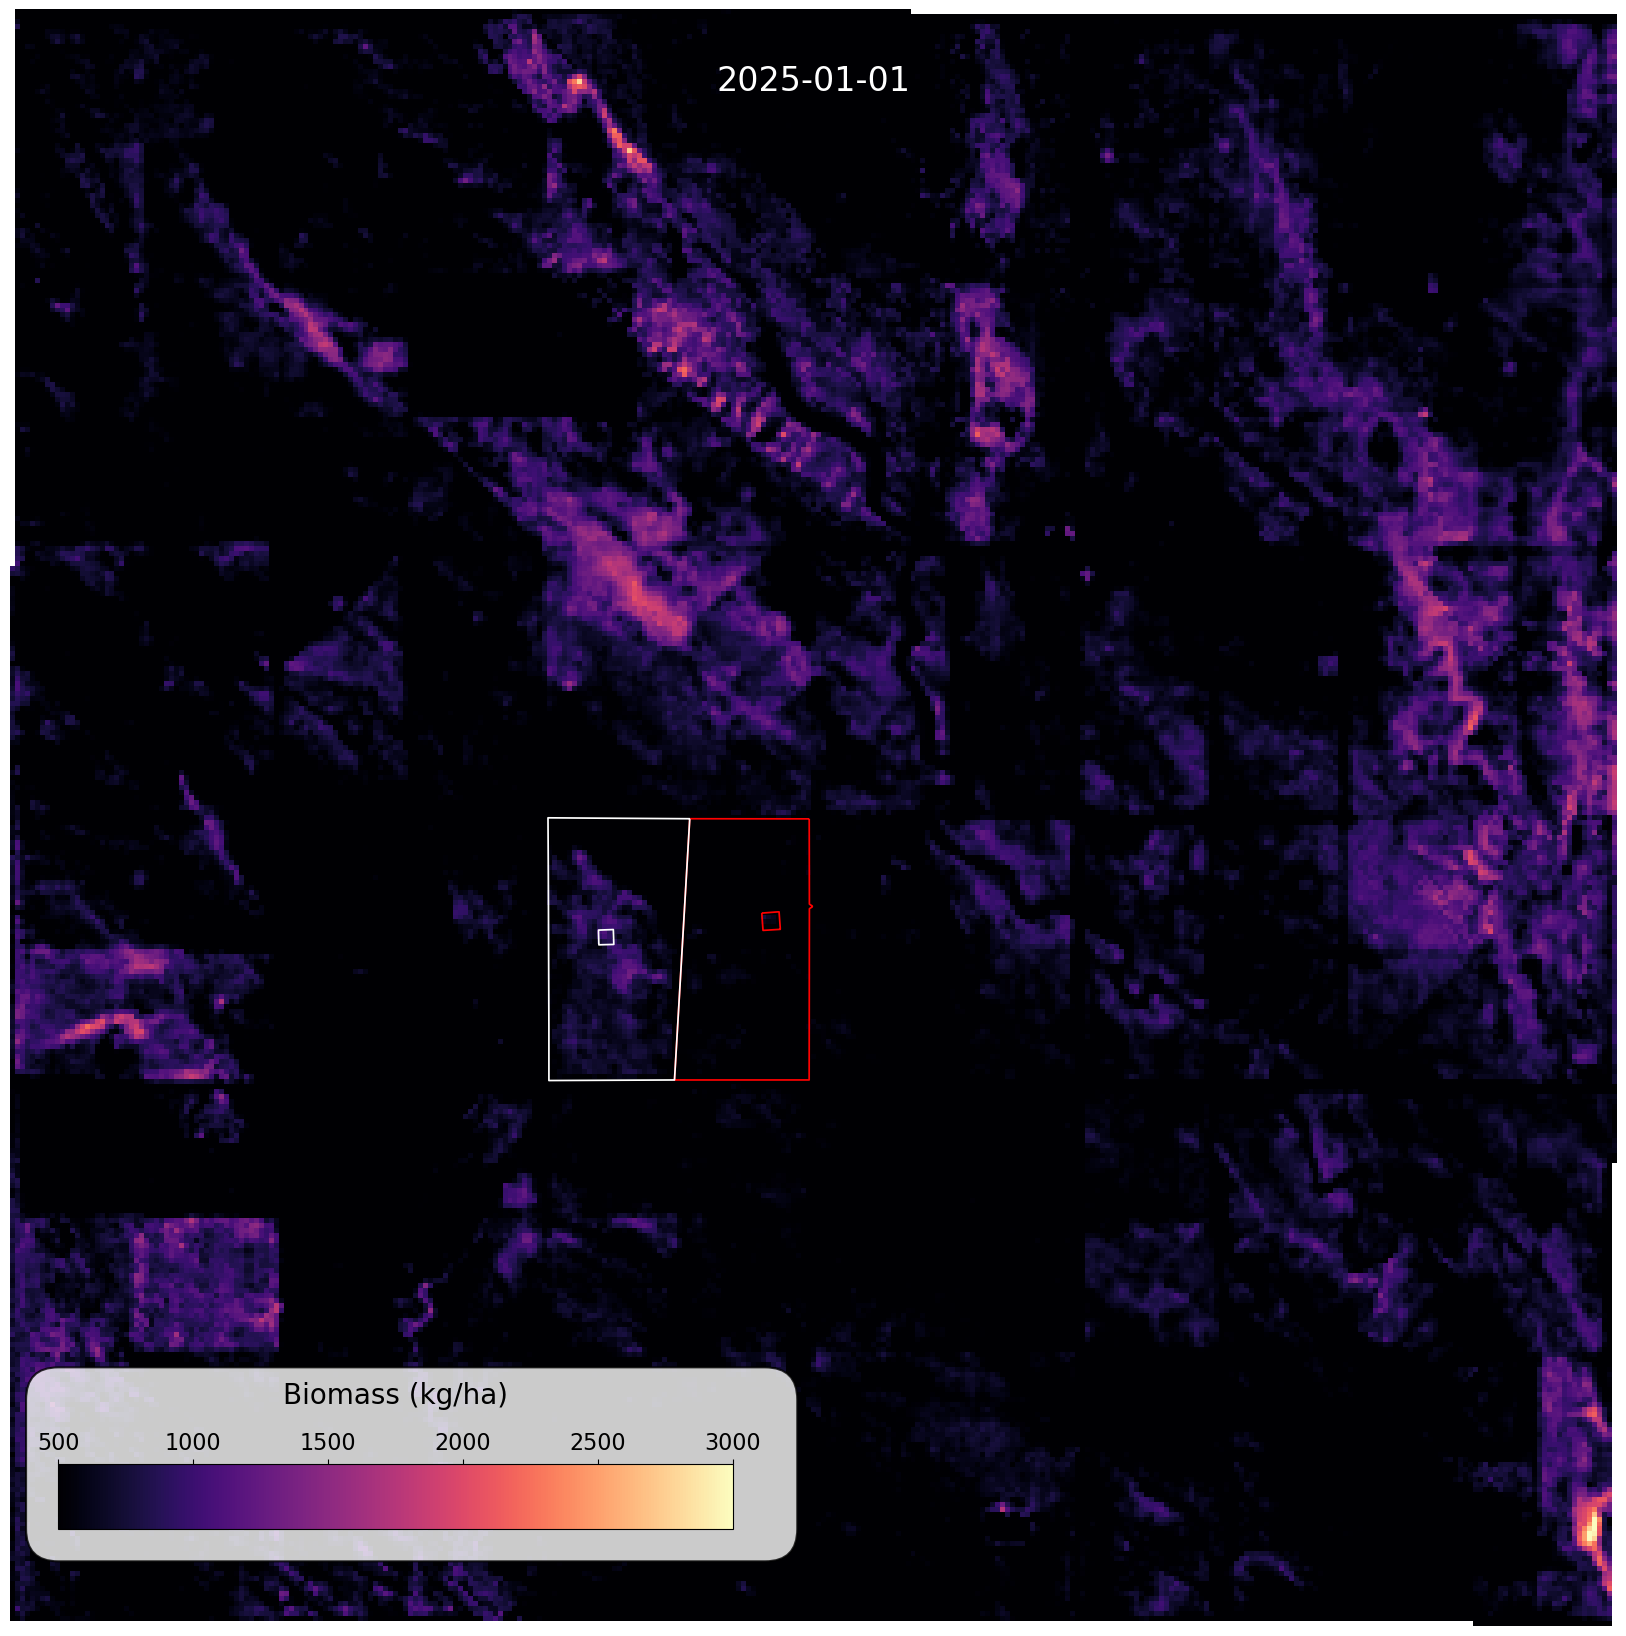

In [77]:
# create figure and axis with automatic size based on pixels/inch set above
fig, ax = plt.subplots(figsize=(len(ds_bm.x)/pixpi_out, len(ds_bm.y)/pixpi_out), layout='constrained')
# turn off axis on map
ax.axis('off')
# plot the image for the first date
im = show(ds_bm.sel(date=dates[0]).data, vmin=500, vmax=3000, animated=True,
              transform=ds_bm.rio.transform(), ax=ax, cmap='magma')
# get the image object for the legend
im_for_legend = im.get_images()[0]
# plot the boundar of the aoi
#gdf_aoi.boundary.plot(ax=ax, edgecolor='white', color=None, linewidth=0.75)
gdf_pasts[gdf_pasts['Past_Name_'] == '23E'].plot(ax=ax, edgecolor='red', facecolor="none", linewidth=1.25)
gdf_pasts[gdf_pasts['Past_Name_'] == '23W'].plot(ax=ax, edgecolor='white', facecolor="none", linewidth=1.25)

# annotate with text for the date
date_text = ax.text(0.5, 0.95, 
                    dates[0].dt.floor('D').dt.strftime("%Y-%m-%d").values,
                    c='white', size=24, horizontalalignment='center', fontweight=500,
                    transform=ax.transAxes, animated=True)

# Add a box in axes coordinates (0–1 range)
box = FancyBboxPatch(
    (0.03, 0.06),          # (x, y) bottom-left corner in axes coords
    0.44, 0.08,            # width, height
    boxstyle="round,pad=0.02",
    transform=ax.transAxes,  # use axes coordinates
    facecolor='white',
    edgecolor='black',
    linewidth=1.5,
    alpha=0.8,
    zorder=5               # draw on top of the image
)
ax.add_patch(box)
# create a colorbar for the map
cax = ax.inset_axes([0.03, 0.06, 0.42, 0.04])
cax.patch.set(facecolor='white', alpha=0.7)
cb = fig.colorbar(im_for_legend, cax=cax, orientation='horizontal', 
                  label='Biomass (kg/ha)',
                 )

# flip the axis ticks and label of the colorbar to be on top
cb.ax.xaxis.set_ticks_position("top")
cb.ax.xaxis.set_label_position("top")
cb.ax.tick_params(labelsize=16)       # tick labels
cb.set_label('Biomass (kg/ha)', size=20)  # colorbar label
cb.ax.xaxis.labelpad = 20  # increase to add more space

In [82]:
# function to update data during animation
def animate_xr_ts(frame):
    im.images[0].set_data(ds_bm.sel(date=dates[frame]).data)
    date_text.set_text(dates[frame].dt.floor('D').dt.strftime("%Y-%m-%d").values)
    return (im, date_text)

# create the animation
ani = animation.FuncAnimation(fig, animate_xr_ts, interval=200,
                              frames=len(dates), repeat=True, repeat_delay=1000)

# specify how to write the output, including frames per second (fps)
writer = animation.PillowWriter(fps=len(dates)//duration_secs)

# save the animation to disk
ani.save(os.path.join('cper_anims', 'cper_bm_anim_light_heavy' + str(yr) + '.gif'),
         dpi=150, #50
         writer=writer,
         savefig_kwargs={'transparent': True, 'pad_inches': 0},
         progress_callback=lambda i, n: print(f'Saving frame {i+1} of {n}', end='\r'))

Saving frame 365 of 365

In [45]:
yr = str(2025)
# input path
inPATH_ndvi_raw = f'/90daydata/cper_neon_aop/hls_nrt/cper/hls_ndvi/cper_hls_ndvi_{yr}_raw.nc'
ds_ndvi_raw = riox.open_rasterio(inPATH_ndvi_raw, masked=True)

inPATH_ndvi = f'/90daydata/cper_neon_aop/hls_nrt/cper/hls_ndvi/cper_hls_ndvi_{yr}.nc'
ds_ndvi = riox.open_rasterio(inPATH_ndvi, masked=True)

inPATH_bm_raw = f'/90daydata/cper_neon_aop/hls_nrt/cper/hls_biomass/cper_hls_bm_{yr}_raw.nc'
ds_bm_raw = riox.open_rasterio(inPATH_bm_raw, masked=True)

inPATH_bm = f'/90daydata/cper_neon_aop/hls_nrt/cper/hls_biomass/cper_hls_bm_{yr}.nc'
ds_bm = riox.open_rasterio(inPATH_bm, masked=True)

inPATH_shp = '../../data/ground/boundaries/cper_pastures_2022_w_exclosures_spk.shp'
gdf_pasts = gpd.read_file(inPATH_shp)
gdf_pasts = gdf_pasts.to_crs(crs=ds_bm.rio.crs.to_epsg())

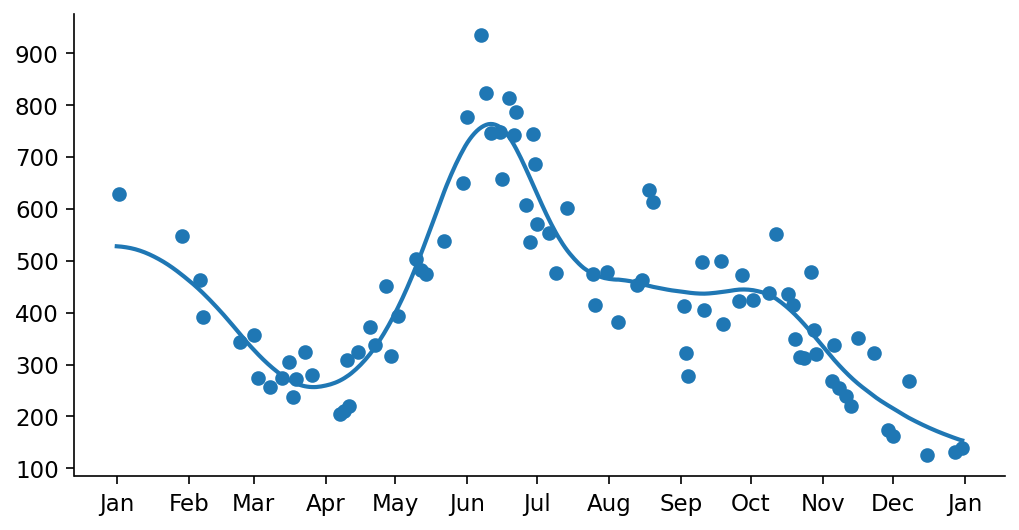

In [59]:
x_idx = 200
y_idx = 200
fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(ds_bm_raw.time.astype("datetime64[ns]"), ds_bm_raw.isel(x=x_idx, y=y_idx))
ax.plot(ds_bm.time.astype("datetime64[ns]"), ds_bm.isel(x=x_idx, y=y_idx))
ax.grid(visible=False)
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))  # 'Jan 2024'

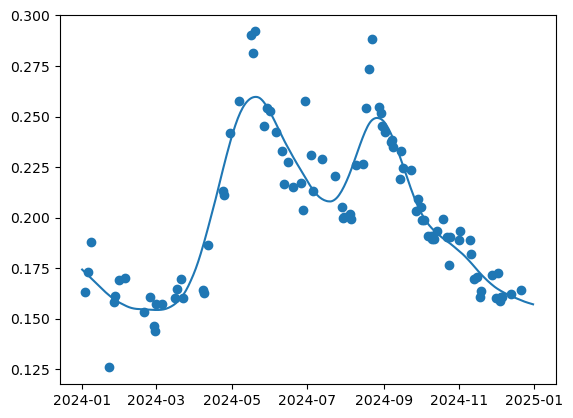

In [3]:
fig, ax = plt.subplots()
ax.scatter(ds_ndvi_raw.time.astype("datetime64[ns]"), ds_ndvi_raw.isel(x=200, y=200))
ax.plot(ds_ndvi.time.astype("datetime64[ns]"), ds_ndvi.isel(x=200, y=200))

#### Helper functions

In [25]:
def full_smooth_ndvi(ts, dates):
    ndvi_min = ts[(dates.dt.month < 3) | (dates.dt.month > 10)].quantile(0.05)
    ts_ds = pd.Series(
        despike_ts(ts.values, dat_thresh=0.025, days_thresh=61)).interpolate(limit=None)
    ts_smooth = pd.Series(double_savgol(ts_ds.values, window2=91), index=ts.index)
    #ts_smooth = pd.Series(savgol_filter(ts_ds, 91, 3), index=ts.index)
    return ts_smooth

def running_mean(x, N):
    cumsum = np.cumsum(np.insert(x, 0, 0))
    return (cumsum[N:] - cumsum[:-N]) / float(N)

# explore creating SOS
def calc_sos(ndvi_ts):
    ndvi_thresh1 = np.nanpercentile(ndvi_ts[91:201], 40.0)
    date_thresh1 = next(x for x in np.where(ndvi_ts > ndvi_thresh1)[0] if x > 30)
    dndvi_ts = np.ones_like(ndvi_ts) * np.nan
    dndvi_ts[25:] = running_mean(np.diff(ndvi_ts), 25)
    dndvi_thresh2 = np.nanpercentile(dndvi_ts[:date_thresh1], 35.0)
    try:
        sos = np.where(dndvi_ts[:date_thresh1] < dndvi_thresh2)[0][-1]
    except IndexError:
        sos = np.nan
    return sos

def weighted_ndvi(ndvi_smooth1, ndvi_smooth2, sos):
    weights1 = np.ones_like(ndvi_smooth1)
    peak = np.argmax(ndvi_smooth1[120:300]) + 120
    weights1[:sos] = 0
    weights1[sos:peak] = np.linspace(0, 1, peak-sos)**4
    weights1[peak:] = np.linspace(1, 0, len(ndvi_smooth1) - peak)**4
    weights2 = 1.0 - weights1
    ndvi_wtd = np.average(np.array([ndvi_smooth1, ndvi_smooth2]), axis=0, weights=np.array([weights1, weights2]))
    return pd.Series(ndvi_wtd, index=ndvi_smooth1.index)
    

#### Prep data

In [26]:
# load the dataset
df_ndvi = pd.read_csv(inPATH_ndvi, parse_dates=[0])

In [27]:
df_ndvi['Year'] = df_ndvi['Date'].dt.year

#### Run secondary smoothing and calculate SOS

In [28]:
# run secondary smoothing on full time series
ndvi_ts_smooth = df_ndvi.groupby('Id').apply(lambda x: full_smooth_ndvi(x['NDVI'], x['Date']))
df_ndvi['NDVI_smooth2'] = ndvi_ts_smooth.droplevel(list(np.arange(ndvi_ts_smooth.index.nlevels-1)))

In [31]:
# calculate start of season as DOY for each plot and year
df_sos = df_ndvi.groupby([df_ndvi['Date'].dt.year, 
                              'Id'])['NDVI_smooth2'].apply(
    lambda x: calc_sos(x)).reset_index().rename(columns={'NDVI_smooth2': 'SOS_doy',
                                                         'Date': 'Year'})
# get as date
df_sos['SOS_date'] = df_sos.apply(lambda x: datetime(x['Year'], 1, 1) + timedelta(days=x['SOS_doy']), axis=1)

# merge with NDVI for plotting
df_sos = pd.merge(df_sos, df_ndvi[['Date', 'Id', 'NDVI_smooth2']], 
         left_on=['SOS_date', 'Id'],
         right_on=['Date', 'Id'], how='left')

In [32]:
df_ndvi#['Id'].unique()

,Date,Id,NDVI,NDVI_smooth,Year,NDVI_smooth2
0,2014-01-01,12C,NaN,0.187145,2014,0.181241
1,2014-01-02,12C,NaN,0.186701,2014,0.182789
2,2014-01-03,12C,NaN,0.186244,2014,0.184247
3,2014-01-04,12C,NaN,0.185762,2014,0.185617
4,2014-01-05,12C,NaN,0.185246,2014,0.186903
...,...,...,...,...,...,...
193551,2023-12-27,WeatherStation,NaN,0.258902,2023,0.259020
193552,2023-12-28,WeatherStation,NaN,0.256688,2023,0.257592
193553,2023-12-29,WeatherStation,0.25528,0.253938,2023,0.256074
193554,2023-12-30,WeatherStation,NaN,0.249644,2023,0.254463


<AxesSubplot:xlabel='SOS_date', ylabel='NDVI_smooth2'>

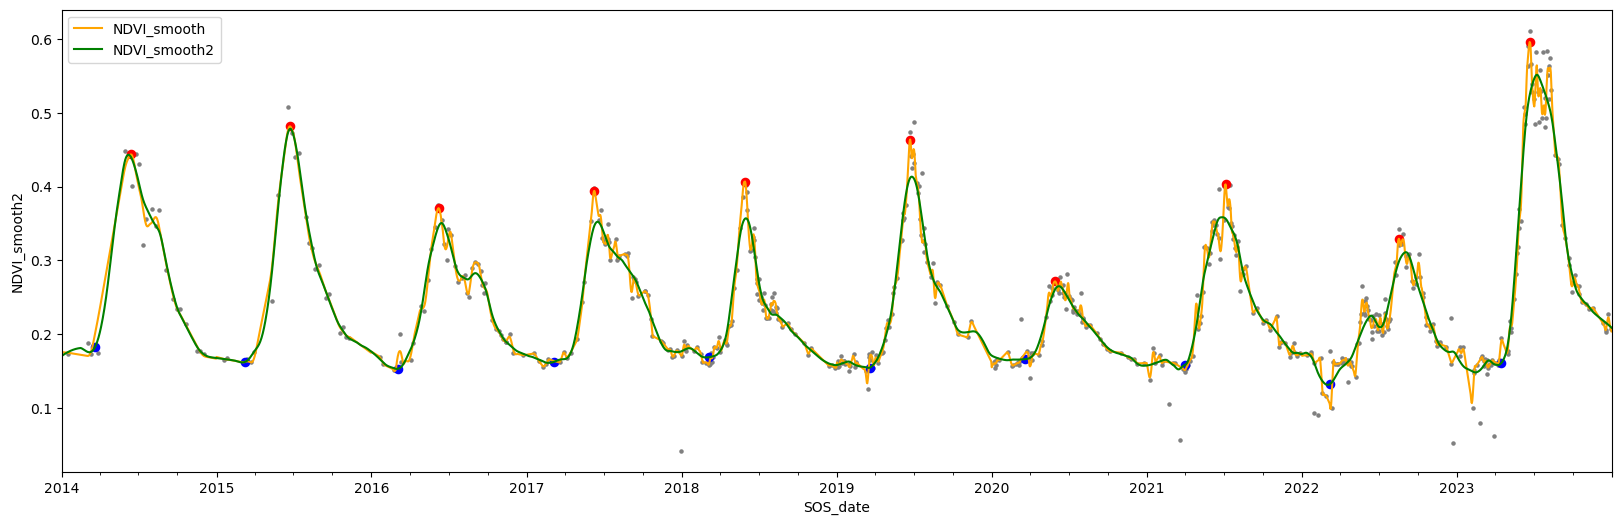

In [33]:
# plot updated smooth with start of season (blue) and peak of season (red)
fig, ax1 = plt.subplots(figsize=(20, 6))
plot = 'Northeast'
ndvi_peak_vals = df_ndvi[df_ndvi['Id'] == plot].groupby('Year').apply(lambda x: x['NDVI_smooth'].iloc[np.argmax(x['NDVI_smooth'])])
ndvi_peak_dates = df_ndvi[df_ndvi['Id'] == plot].groupby('Year').apply(lambda x: x['Date'].iloc[np.argmax(x['NDVI_smooth'])])
df_ndvi[df_ndvi['Id'] == plot].plot.scatter(x='Date', y='NDVI', ax=ax1, c='grey', s=5)
df_ndvi[df_ndvi['Id'] == plot].plot(x='Date', y='NDVI_smooth', c='orange', ax=ax1)
df_ndvi[df_ndvi['Id'] == plot].plot(x='Date', y='NDVI_smooth2', c='green', ax=ax1)
ax1.scatter(ndvi_peak_dates.values, ndvi_peak_vals.values, c='red', s=35)
df_sos[df_sos['Id'] == plot].plot.scatter(x='SOS_date', y='NDVI_smooth2',  ax=ax1, c='blue', s=35)

In [34]:
# get average from two smooths, weighted by distance to SOS and peak NDVI 
ndvi_smooth_avg = df_ndvi.groupby(['Year', 'Id']).apply(lambda x: weighted_ndvi(x['NDVI_smooth'], 
                                                                  x['NDVI_smooth2'],
                                                                  df_sos[(df_sos['Year'] == x.name[0]) & 
                                                                         (df_sos['Id'] == x.name[1])]['SOS_doy'].values[0]))
df_ndvi['NDVI_smooth_avg'] = ndvi_smooth_avg.droplevel(list(np.arange(ndvi_smooth_avg.index.nlevels-1)))

<AxesSubplot:xlabel='Date', ylabel='NDVI_smooth2'>

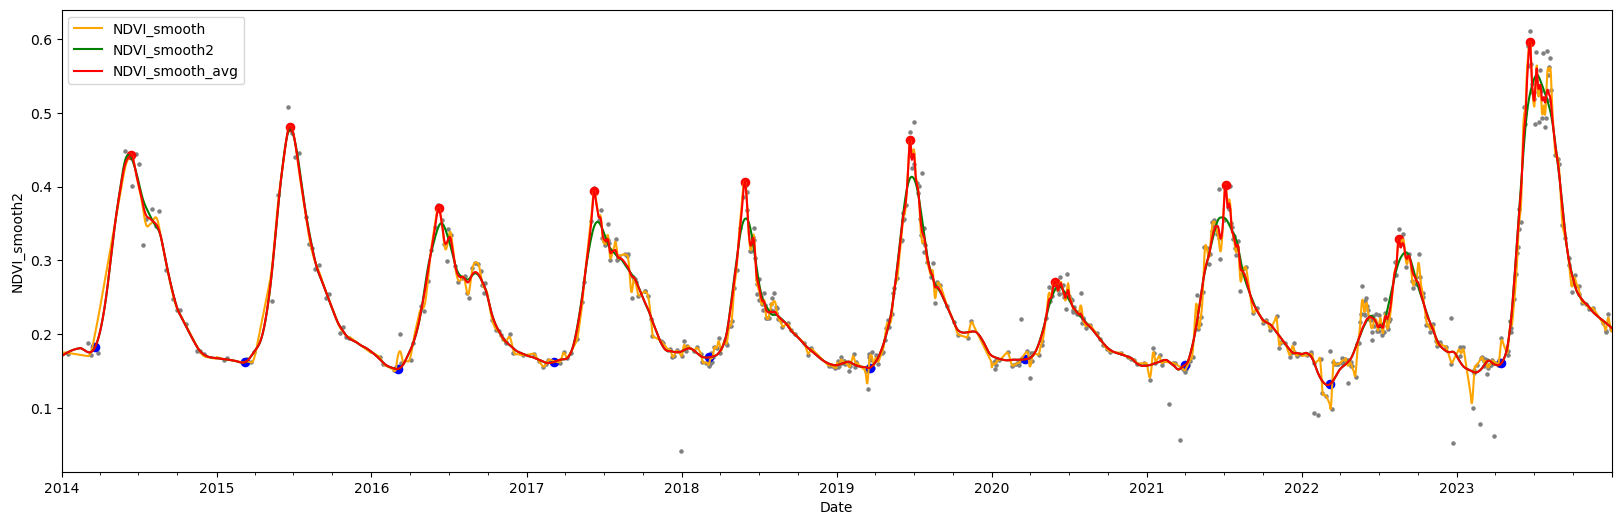

In [35]:
fig, ax1 = plt.subplots(figsize=(20, 6))
plot = 'Northeast'
ndvi_peak_vals = df_ndvi[df_ndvi['Id'] == plot].groupby('Year').apply(lambda x: x['NDVI_smooth'].iloc[np.argmax(x['NDVI_smooth'])])
ndvi_peak_dates = df_ndvi[df_ndvi['Id'] == plot].groupby('Year').apply(lambda x: x['Date'].iloc[np.argmax(x['NDVI_smooth'])])
df_ndvi[df_ndvi['Id'] == plot].plot.scatter(x='Date', y='NDVI', ax=ax1, c='grey', s=5)
df_ndvi[df_ndvi['Id'] == plot].plot(x='Date', y='NDVI_smooth', c='orange', ax=ax1)
df_ndvi[df_ndvi['Id'] == plot].plot(x='Date', y='NDVI_smooth2', c='green', ax=ax1)
ax1.scatter(ndvi_peak_dates.values, ndvi_peak_vals.values, c='red', s=35)
df_sos[df_sos['Id'] == plot].plot.scatter(x='SOS_date', y='NDVI_smooth2',  ax=ax1, c='blue', s=35)
df_ndvi[df_ndvi['Id'] == plot].plot(x='Date', y='NDVI_smooth_avg', ax=ax1, c='red')